# Protocolo de fixes para ciclo externo

**Objetivo:** evaluar 5 estrategias para mejorar la generación DDPM y la recuperación
de parámetros cuando se usa un dataset externo cuya distribución de parámetros
no coincide perfectamente con el dataset de entrenamiento.

**Problema identificado (diagnóstico previo):**
- `Hex` fuera de rango del scaler en 18.4 % de las muestras externas
- Xception falla para Kan1 / KanS en el régimen de alto campo
- Métricas pixel (MSE/SSIM) sesgadas por la diferencia física entre datasets

## Las 5 ideas
| # | Idea | Qué cambia |
|---|------|------------|
| 1 | Saturación suave de Hex (clamp vs tanh) | Condicionamiento DDPM |
| 2 | Curva de calibración post-hoc para Xception | Predicciones de θ |
| 3 | Expansión de `scaler_inv` al rango unión | Desnormalización Xception |
| 4 | Observables físicos en lugar de métricas pixel | Evaluación de imagen |
| 5 | Evaluación filtrada por régimen (Hex in/out range) | Protocolo de reporte |

> **Kaggle:** agrega los 4 datasets desde **+ Add Data** antes de ejecutar.

In [1]:
import subprocess, sys
def pip(pkg): subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
pip("scikit-image")
pip("scipy")

import os, math, time, gc, warnings
warnings.filterwarnings("ignore")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.linear_model import LinearRegression
from scipy.stats import wasserstein_distance
from skimage.metrics import structural_similarity as ssim_fn

for gpu in tf.config.list_physical_devices("GPU"):
    try: tf.config.experimental.set_memory_growth(gpu, True)
    except: pass

# Pin to cuda:0 explicitly — Kaggle multi-GPU envs can shift the default
# after TensorFlow initializes, causing device mismatch errors.
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device : {DEVICE}")
print(f"TensorFlow     : {tf.__version__}")
print(f"PyTorch        : {torch.__version__}")

2026-06-08 22:09:27.811109: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780956568.215660      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780956568.334660      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780956569.360630      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780956569.360691      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780956569.360694      23 computation_placer.cc:177] computation placer alr

PyTorch device : cuda:0
TensorFlow     : 2.19.0
PyTorch        : 2.10.0+cu128


In [2]:
# ── Rutas Kaggle ──────────────────────────────────────────────────────────────
BASE = "/kaggle/input/datasets/carloscanamejoy"
DATASET_ORIG_PATH = Path(f"{BASE}/dataset-spines-united-v2/dataset_unificado_v2.npz")
DATASET_EXT_PATH  = Path(f"{BASE}/dataset-external-hez-new/dataset-hez-external.npz")
XCEPTION_WEIGHTS  = Path(f"{BASE}/weights-xception-model/modelo_xception_fulldatabaseV3100.h5")
DDPM_CHECKPOINT   = Path(f"{BASE}/weights-models/ddpm_spines_final_39crop.pt")

for p in [DATASET_ORIG_PATH, DATASET_EXT_PATH, XCEPTION_WEIGHTS, DDPM_CHECKPOINT]:
    print(f"[{'OK' if p.exists() else 'FALTA'}]  {p}")

# ── Constantes ────────────────────────────────────────────────────────────────
PARAM_NAMES  = ["T", "Jex2", "Jex3", "Jex4", "Kan1", "KanS", "Hex", "KDM"]
ACTIVE_PARAMS = ["T", "Kan1", "KanS", "Hex", "KDM"]   # Jex2/3/4=0 siempre en externo
ACTIVE_IDX    = [PARAM_NAMES.index(p) for p in ACTIVE_PARAMS]
HEX_IDX       = PARAM_NAMES.index("Hex")   # 6
GRID          = 39
IMG_SIZE      = 40
RD_PIXELS     = 18.3
SEED          = 42

# Evaluación
N_EVAL        = 500   # muestras del externo para evaluar cada idea
N_CAL         = 300   # muestras de calibración (Idea 2)
DDPM_STEPS    = 100
BATCH_GEN     = 64
BATCH_XCEP    = 32

rng_eval = np.random.RandomState(7)
rng_cal  = np.random.RandomState(13)

[OK]  /kaggle/input/datasets/carloscanamejoy/dataset-spines-united-v2/dataset_unificado_v2.npz
[OK]  /kaggle/input/datasets/carloscanamejoy/dataset-external-hez-new/dataset-hez-external.npz
[OK]  /kaggle/input/datasets/carloscanamejoy/weights-xception-model/modelo_xception_fulldatabaseV3100.h5
[OK]  /kaggle/input/datasets/carloscanamejoy/weights-models/ddpm_spines_final_39crop.pt


In [ ]:
# ── Cargar datasets ───────────────────────────────────────────────────────────
data_orig   = np.load(DATASET_ORIG_PATH, mmap_mode="r")
imgs_orig   = data_orig["img"]          # (N_o, 39, 39, 1)
params_orig = np.asarray(data_orig["params"])
N_orig      = imgs_orig.shape[0]

data_ext    = np.load(DATASET_EXT_PATH, mmap_mode="r")
imgs_ext    = data_ext["img"]           # (N_e, 39, 39, 1)
params_ext  = np.asarray(data_ext["params"])
N_ext       = imgs_ext.shape[0]

print(f"Original : {N_orig:,} muestras  imgs={imgs_orig.shape}")
print(f"Externo  : {N_ext:,}  muestras  imgs={imgs_ext.shape}")

# ── Scalers sobre SOLO el train del dataset ORIGINAL ─────────────────────────
all_idx = np.arange(N_orig)
idx_tr_pool, idx_te, _, _ = train_test_split(all_idx, params_orig, test_size=0.15, random_state=SEED)
idx_tr, idx_val, _, _     = train_test_split(idx_tr_pool, params_orig[idx_tr_pool], test_size=0.1765, random_state=SEED)
scaler_inv  = MinMaxScaler().fit(params_orig[idx_tr])

idx_all_ddpm = np.arange(N_orig)
idx_tr_ddpm, _ = train_test_split(idx_all_ddpm, test_size=0.30, random_state=SEED)
scaler_ddpm = MinMaxScaler().fit(params_orig[idx_tr_ddpm])

# mn/mx de imagen sobre imágenes paddeadas del train DDPM
sample40 = np.pad(
    np.asarray(imgs_orig[idx_tr_ddpm[:5000]]).astype(np.float32)[..., 0],
    ((0,0),(0,1),(0,1)), mode='reflect'
)
MN, MX = float(sample40.min()), float(sample40.max())

print(f"\nscaler_ddpm Hex → [{scaler_ddpm.data_min_[HEX_IDX]:.4f}, {scaler_ddpm.data_max_[HEX_IDX]:.4f}]")
print(f"Hex externo      → [{params_ext[:, HEX_IDX].min():.4f}, {params_ext[:, HEX_IDX].max():.4f}]")
HEX_MAX_TRAIN = scaler_ddpm.data_max_[HEX_IDX]
HEX_MAX_EXT   = params_ext[:, HEX_IDX].max()
n_oor = int(np.sum(params_ext[:, HEX_IDX] > HEX_MAX_TRAIN))
print(f"Hex fuera de rango: {n_oor}/{N_ext} = {100*n_oor/N_ext:.1f}%")
print(f"MN={MN:.4f}  MX={MX:.4f}")

# Subconjunto de evaluación (mismo para todas las ideas)
eval_idx = rng_eval.choice(N_ext, N_EVAL, replace=False)
y_eval   = params_ext[eval_idx].astype(np.float32)
imgs_ref = np.asarray(imgs_ext[eval_idx]).astype(np.float32)   # (N_EVAL, 39, 39, 1)

# Referencia normalizada a [-1,1] — disponible globalmente para show_samples
imgs_ref_39   = imgs_ref[..., 0]   # (N_EVAL, 39, 39)
imgs_ref_norm = (imgs_ref_39 - MN) / (MX - MN + 1e-8) * 2 - 1

In [4]:
# ── Arquitectura DDPM ─────────────────────────────────────────────────────────
def sinusoidal_embedding(t, dim):
    half  = dim // 2
    freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device).float() / (half-1))
    args  = t[:, None].float() * freqs[None]
    return torch.cat([args.sin(), args.cos()], dim=-1)

class TimeCondEmbedding(nn.Module):
    def __init__(self, t_dim, cond_in, out_dim):
        super().__init__()
        self.t_mlp = nn.Sequential(nn.Linear(t_dim, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim))
        self.c_mlp = nn.Sequential(nn.Linear(cond_in, out_dim), nn.SiLU(), nn.Linear(out_dim, out_dim))
    def forward(self, t, cond):
        return self.t_mlp(sinusoidal_embedding(t, self.t_mlp[0].in_features)) + self.c_mlp(cond)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, emb_dim, groups=8, dropout=0.0):
        super().__init__()
        self.norm1 = nn.GroupNorm(groups, in_ch);   self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(groups, out_ch);  self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, out_ch)
        self.dropout  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, emb):
        h = F.silu(self.norm1(x)); h = self.conv1(h)
        h = h + self.emb_proj(F.silu(emb))[:, :, None, None]
        h = F.silu(self.norm2(h)); h = self.dropout(h); h = self.conv2(h)
        return h + self.skip(x)

class SelfAttention(nn.Module):
    def __init__(self, ch, groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, ch)
        self.qkv  = nn.Conv2d(ch, ch*3, 1); self.proj = nn.Conv2d(ch, ch, 1)
    def forward(self, x):
        B, C, H, W = x.shape; h = self.norm(x)
        q, k, v = self.qkv(h).chunk(3, dim=1)
        q = q.reshape(B,C,-1); k = k.reshape(B,C,-1); v = v.reshape(B,C,-1)
        attn = torch.softmax(torch.bmm(q.transpose(1,2), k) / math.sqrt(C), dim=-1)
        return x + self.proj(torch.bmm(v, attn.transpose(1,2)).reshape(B, C, H, W))

class ConditionalUNet(nn.Module):
    def __init__(self, img_channels=1, base_ch=64, ch_mults=(1,2,4),
                 cond_dim=8, emb_dim=128, dropout=0.0):
        super().__init__()
        chs = [base_ch*m for m in ch_mults]
        self.emb     = TimeCondEmbedding(t_dim=emb_dim, cond_in=cond_dim, out_dim=emb_dim)
        self.conv_in = nn.Conv2d(img_channels, chs[0], 3, padding=1)
        self.down_blocks  = nn.ModuleList(); self.down_samples = nn.ModuleList(); self.skip_channels = []
        in_ch = chs[0]
        for i, out_ch in enumerate(chs):
            self.down_blocks.append(nn.ModuleList([ResBlock(in_ch, out_ch, emb_dim, dropout=dropout),
                                                   ResBlock(out_ch, out_ch, emb_dim, dropout=dropout)]))
            self.skip_channels.append(out_ch)
            self.down_samples.append(nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1) if i < len(chs)-1 else nn.Identity())
            in_ch = out_ch
        self.mid_block1 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
        self.mid_attn   = SelfAttention(chs[-1])
        self.mid_block2 = ResBlock(chs[-1], chs[-1], emb_dim, dropout=dropout)
        self.up_blocks  = nn.ModuleList(); self.up_samples = nn.ModuleList()
        for i, out_ch in enumerate(reversed(chs)):
            skip_ch = self.skip_channels[-(i+1)]
            self.up_blocks.append(nn.ModuleList([ResBlock(in_ch+skip_ch, out_ch, emb_dim, dropout=dropout),
                                                 ResBlock(out_ch, out_ch, emb_dim, dropout=dropout)]))
            self.up_samples.append(nn.ConvTranspose2d(out_ch, out_ch, 4, stride=2, padding=1) if i < len(chs)-1 else nn.Identity())
            in_ch = out_ch
        self.norm_out = nn.GroupNorm(8, chs[0])
        self.conv_out = nn.Conv2d(chs[0], img_channels, 1)
    def forward(self, x, t, cond):
        emb = self.emb(t, cond); h = self.conv_in(x); skips = []
        for (rb1, rb2), ds in zip(self.down_blocks, self.down_samples):
            h = rb1(h, emb); h = rb2(h, emb); skips.append(h); h = ds(h)
        h = self.mid_block1(h, emb); h = self.mid_attn(h); h = self.mid_block2(h, emb)
        for (rb1, rb2), us, sk in zip(self.up_blocks, self.up_samples, reversed(skips)):
            h = torch.cat([h, sk], dim=1); h = rb1(h, emb); h = rb2(h, emb); h = us(h)
        return self.conv_out(F.silu(self.norm_out(h)))

class DDPMScheduler:
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, schedule="cosine", device="cpu"):
        self.T = T
        if schedule == "cosine":
            steps = T+1; s = 0.008
            x  = torch.linspace(0, T, steps, device=device)
            ac = torch.cos(((x/T)+s)/(1+s)*math.pi*0.5)**2; ac = ac/ac[0]
            betas = (1-ac[1:]/ac[:-1]).clamp(max=0.999)
        else:
            betas = torch.linspace(beta_start, beta_end, T, device=device)
        alphas = 1.0 - betas; ac = torch.cumprod(alphas, dim=0)
        self.betas = betas; self.alphas_cumprod = ac
        self.sqrt_ac   = ac.sqrt()
        self.sqrt_1mac = (1.0 - ac).sqrt()

@torch.no_grad()
def ddpm_sample(model, cond_t, scheduler, n_steps=100):
    """(B,8) conditioning tensor → (B,40,40) images in [-1,1]."""
    # Ensure everything runs on the model's actual device.
    dev = next(model.parameters()).device
    cond_t = cond_t.to(dev)
    B = cond_t.shape[0]
    x = torch.randn(B, 1, IMG_SIZE, IMG_SIZE, device=dev)
    # Move scheduler lookup tables to the model device once per call.
    sqrt_ac   = scheduler.sqrt_ac.to(dev)
    sqrt_1mac = scheduler.sqrt_1mac.to(dev)
    timesteps = list(range(0, scheduler.T, scheduler.T // n_steps))[::-1]
    for t_val in timesteps:
        t_t  = torch.full((B,), t_val, device=dev, dtype=torch.long)
        eps  = model(x, t_t, cond_t)
        sa   = sqrt_ac[t_val]; s1a = sqrt_1mac[t_val]
        x0   = ((x - s1a*eps) / sa).clamp(-1, 1)
        if t_val > 0:
            t_prev = max(t_val - scheduler.T // n_steps, 0)
            x = sqrt_ac[t_prev]*x0 + sqrt_1mac[t_prev]*eps
        else:
            x = x0
    return x[:, 0].cpu().numpy()   # (B, 40, 40)

print("Arquitectura DDPM definida.")

Arquitectura DDPM definida.


In [5]:
# ── Cargar DDPM ───────────────────────────────────────────────────────────────
ckpt = torch.load(DDPM_CHECKPOINT, map_location=DEVICE, weights_only=False)
hp   = ckpt["hyperparams"]
print(f"Hiperparámetros DDPM: {hp}")

ddpm = ConditionalUNet(
    img_channels=1, base_ch=hp["base_ch"], ch_mults=(1,2,4),
    cond_dim=8, emb_dim=hp["cond_emb_dim"], dropout=0.0,
).to(DEVICE)
state = ckpt["ema"] if ("ema" in ckpt and ckpt["ema"] is not None) else ckpt["model"]
ddpm.load_state_dict(state); ddpm.eval()

# Always build the scheduler on the device where the model actually landed.
MODEL_DEVICE = next(ddpm.parameters()).device
print(f"DDPM loaded on : {MODEL_DEVICE}")
scheduler = DDPMScheduler(T=1000, schedule=hp["beta_schedule"], device=MODEL_DEVICE)
print(f"DDPM cargado (EMA={'ema' in ckpt and ckpt['ema'] is not None}).")

# ── Cargar Xception ───────────────────────────────────────────────────────────
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model

def build_xception(n_out=8):
    inp  = Input(shape=(224, 224, 3))
    base = Xception(weights=None, include_top=False, input_tensor=inp)
    x = GlobalAveragePooling2D()(base.output)
    x = BatchNormalization(name="batch_normalization_4")(x)
    x = Dropout(0.4, name="dropout")(x)
    x = Dense(256, activation="relu", name="dense")(x)
    x = BatchNormalization(name="batch_normalization_5")(x)
    x = Dropout(0.3, name="dropout_1")(x)
    return Model(inp, Dense(n_out, activation="linear", name="dense_1")(x))

with tf.device("/cpu:0"):
    xception = build_xception()
    xception.load_weights(XCEPTION_WEIGHTS)
print(f"Xception cargado. Params={xception.count_params():,}")

Hiperparámetros DDPM: {'lr': 0.00022640535194211016, 'batch_size': 128, 'base_ch': 80, 'cond_emb_dim': 128, 'dropout': 0.1, 'beta_schedule': 'cosine', 'ema_decay': 0.999, 'weight_decay': 4.279388675327132e-05, 'min_snr_gamma': 5.0}
DDPM loaded on : cuda:0
DDPM cargado (EMA=True).


I0000 00:00:1780956603.128688      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13525 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780956603.134119      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Xception cargado. Params=21,397,296


In [ ]:
# ── Utilidades: generación e inferencia ──────────────────────────────────────

def generate_batch(cond_norm, n_steps=DDPM_STEPS):
    """(N,8) condicionamiento normalizado → (N,40,40) imágenes [-1,1]."""
    # ddpm_sample moves cond_t to the model's device internally, so we
    # pass tensors on CPU here and let the sample function handle placement.
    imgs_out = []
    for s in range(0, len(cond_norm), BATCH_GEN):
        c = torch.tensor(cond_norm[s:s+BATCH_GEN], dtype=torch.float32)
        imgs_out.append(ddpm_sample(ddpm, c, scheduler, n_steps=n_steps))
    return np.concatenate(imgs_out, axis=0)   # (N, 40, 40)

def xception_infer(imgs_40, scaler_out=None):
    """
    (N,40,40) imágenes DDPM → (N,8) parámetros físicos.
    scaler_out: scaler a usar para inverse_transform (default: scaler_inv).
    """
    if scaler_out is None: scaler_out = scaler_inv
    imgs = imgs_40[:, :39, :39].astype(np.float32)    # crop
    imgs = (imgs + 1.0) / 2.0 * (MX - MN) + MN        # físico
    results = []
    with tf.device("/cpu:0"):
        for s in range(0, len(imgs), BATCH_XCEP):
            chunk = imgs[s:s+BATCH_XCEP][..., None]    # (B,39,39,1)
            chunk = tf.image.resize(chunk, (224, 224))
            chunk = tf.image.grayscale_to_rgb(chunk)
            y_n   = xception.predict(chunk, verbose=0)
            results.append(scaler_out.inverse_transform(y_n))
    return np.concatenate(results, axis=0)             # (N, 8)

def r2_table(y_true, y_pred, label=""):
    """Imprime R² y MAE para los parámetros activos."""
    rows = []
    for j, name in zip(ACTIVE_IDX, ACTIVE_PARAMS):
        yt = y_true[:, j]; yp = y_pred[:, j]
        if yt.std() < 1e-8: continue
        r2  = r2_score(yt, yp)
        mae = mean_absolute_error(yt, yp)
        rows.append({"param": name, "R2": r2, "MAE": mae})
    df = pd.DataFrame(rows)
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  {'param':<6} {'R²':>8} {'MAE':>10}")
    for _, row in df.iterrows():
        flag = " ✓" if row.R2 > 0.7 else (" ~" if row.R2 > 0.3 else " ✗")
        print(f"  {row.param:<6} {row.R2:8.4f} {row.MAE:10.4f}{flag}")
    print(f"  {'mean':>6} {df.R2.mean():8.4f} {df.MAE.mean():10.4f}")
    return df

def show_samples(imgs_gen, imgs_ref_norm, y_params, label,
                 n_in=4, n_out=4, fname=None):
    """
    Qualitative panel: Reference | Generated | |Difference| for n_in in-range
    and n_out out-of-range samples (by Hex).

    imgs_gen      : (N,40,40) generated images in [-1,1]
    imgs_ref_norm : (N,39,39) reference images in [-1,1]
    y_params      : (N,8) physical parameters (used for Hex regime and title)
    label         : string title for the figure
    """
    in_idx  = np.where(y_params[:, HEX_IDX] <= HEX_MAX_TRAIN)[0]
    out_idx = np.where(y_params[:, HEX_IDX] >  HEX_MAX_TRAIN)[0]

    # Pick evenly-spaced samples so we cover the Hex range, not just the first few
    def pick(idx, n):
        if len(idx) == 0:
            return np.array([], dtype=int)
        step = max(1, len(idx) // n)
        return idx[::step][:n]

    sel_in  = pick(in_idx,  n_in)
    sel_out = pick(out_idx, n_out)
    sel     = np.concatenate([sel_in, sel_out])
    n_total = len(sel)
    if n_total == 0:
        print(f"[show_samples] No samples to display for '{label}'")
        return

    # 3 columns per sample: Reference, Generated, |Diff|
    ncols = 3
    fig, axes = plt.subplots(n_total, ncols,
                             figsize=(ncols * 2.8, n_total * 2.6),
                             squeeze=False)
    fig.suptitle(label, fontsize=13, fontweight="bold", y=1.01)

    col_titles = ["Reference (external)", "Generated (DDPM)", "|Difference|"]
    for ax, ct in zip(axes[0], col_titles):
        ax.set_title(ct, fontsize=10, fontweight="bold")

    for row, idx in enumerate(sel):
        ref = imgs_ref_norm[idx]                        # (39,39) in [-1,1]
        gen = imgs_gen[idx, :39, :39]                   # (39,39) in [-1,1]
        diff = np.abs(ref - gen)

        hex_val = y_params[idx, HEX_IDX]
        regime  = "OUT" if hex_val > HEX_MAX_TRAIN else "in"
        row_label = (f"Hex={hex_val:.3f} [{regime}]  "
                     f"T={y_params[idx, PARAM_NAMES.index('T')]:.1f}  "
                     f"KDM={y_params[idx, PARAM_NAMES.index('KDM')]:.3f}")

        kw_img  = dict(cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")
        kw_diff = dict(cmap="hot",    vmin=0,  vmax=1, interpolation="nearest")

        im0 = axes[row, 0].imshow(ref,  **kw_img)
        im1 = axes[row, 1].imshow(gen,  **kw_img)
        im2 = axes[row, 2].imshow(diff, **kw_diff)

        # MAE annotation on difference panel
        mae_px = float(diff.mean())
        ssim_v = ssim_fn(ref, gen, data_range=2.0)
        axes[row, 2].set_xlabel(f"MAE={mae_px:.3f}  SSIM={ssim_v:.3f}", fontsize=8)

        axes[row, 0].set_ylabel(row_label, fontsize=7, rotation=0,
                                labelpad=130, va="center")

        for ax in axes[row]:
            ax.set_xticks([]); ax.set_yticks([])

        # Shared colorbar for ref/gen on last column only to save space
        if row == 0:
            plt.colorbar(im0, ax=axes[row, 1], fraction=0.046, pad=0.04)
            plt.colorbar(im2, ax=axes[row, 2], fraction=0.046, pad=0.04)

    # Divider line between in-range and out-of-range blocks
    if len(sel_in) > 0 and len(sel_out) > 0:
        div_y = (len(sel_in) - 0.5) / n_total
        fig.add_artist(
            plt.Line2D([0.08, 0.92], [1 - div_y, 1 - div_y],
                       transform=fig.transFigure, color="gray",
                       linewidth=1.2, linestyle="--")
        )
        fig.text(0.01, 1 - div_y + 0.01, "▲ in-range", fontsize=8,
                 color="steelblue", transform=fig.transFigure, va="bottom")
        fig.text(0.01, 1 - div_y - 0.01, "▼ out-of-range", fontsize=8,
                 color="tomato", transform=fig.transFigure, va="top")

    plt.tight_layout()
    if fname:
        plt.savefig(fname, dpi=130, bbox_inches="tight")
        print(f"Guardado: {fname}")
    plt.show()

print("Utilidades definidas.")

---
## Baseline — ciclo sin correcciones
Condicionamiento con **hard clamp** de Hex al máximo del scaler.

In [7]:
def cond_clamp(params):
    """Clamp duro de todos los parámetros al rango del scaler y normaliza."""
    p = params.copy().astype(np.float32)
    p = np.clip(p, scaler_ddpm.data_min_, scaler_ddpm.data_max_)
    return scaler_ddpm.transform(p)

print("Generando imágenes baseline (hard clamp)...")
t0 = time.time()
cond_base   = cond_clamp(y_eval)
imgs_base   = generate_batch(cond_base)
y_pred_base = xception_infer(imgs_base)
print(f"OK en {time.time()-t0:.1f}s")
df_base = r2_table(y_eval, y_pred_base, "BASELINE (hard clamp)")

Generando imágenes baseline (hard clamp)...


I0000 00:00:1780956702.683458      78 service.cc:152] XLA service 0x7fa33400c0b0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780956702.683569      78 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1780956704.672637      78 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


OK en 445.8s

  BASELINE (hard clamp)
  param        R²        MAE
  T        0.8822     0.8329 ✓
  Kan1    -1.7184     0.0787 ✗
  KanS    -2.3581     0.0908 ✗
  Hex     -1.4910     0.5421 ✗
  KDM      0.2699     0.2101 ✗
    mean  -0.8831     0.3509


In [ ]:
show_samples(
    imgs_base, imgs_ref_norm, y_eval,
    label="BASELINE — Análisis cualitativo (hard clamp)\n"
          "Referencia externa vs generación DDPM (RdBu_r: azul=↓, rojo=↑ espín)",
    n_in=4, n_out=4,
    fname="qualitative_baseline.png",
)

---
## Idea 1 — Saturación suave de Hex

**Problema:** el hard clamp colapsa todos los valores `Hex > Hex_max` al mismo conditioning
(`c_Hex = 1.0`), haciendo que el 18.4 % de las muestras sean indistinguibles para el DDPM.

**Fix:** aplicar una función de saturación suave que:
- Es aproximadamente identidad para `Hex` pequeño (no distorsiona muestras in-range)
- Comprime `Hex > Hex_max` hacia el interior de `[0,1]` en lugar de colapsarlas a 1

**Variante 1a — Clamp duro** (baseline, referencia)  
**Variante 1b — Saturación tanh:**
$$c_{\text{Hex}} = \tanh\!\left(\frac{\text{Hex}}{\text{Hex}_{\max}}\right)$$
Propiedades: `f(0)=0`, `f(Hex_max)≈0.76`, `f(∞)→1`. Monotónica, diferenciable,
sin discontinuidad en el borde.

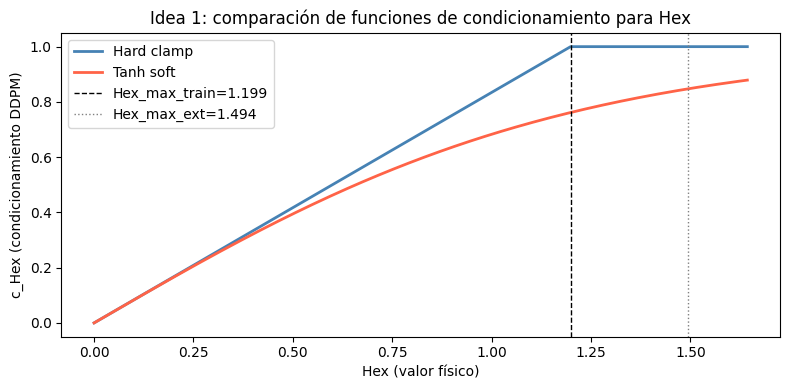

Generando imágenes Idea 1b (tanh)...
OK en 472.1s

  IDEA 1b — Saturación tanh de Hex
  param        R²        MAE
  T        0.9138     0.7512 ✓
  Kan1    -1.9626     0.0819 ✗
  KanS    -2.2380     0.0892 ✗
  Hex     -1.5156     0.5483 ✗
  KDM      0.4630     0.1790 ~
    mean  -0.8679     0.3299

Muestras con Hex fuera de rango: 94/500
  c_Hex clamp → media=1.0000 (todos = 1.0)
  c_Hex tanh  → media=0.8062 (variedad preservada)


In [8]:
def cond_tanh_hex(params):
    """
    Saturación tanh solo para Hex. Resto de parámetros: scaler normal con clamp.
    El tanh mapea [0, ∞) → [0, 1) de forma suave y monotónica.
    """
    p = params.copy().astype(np.float64)
    # Aplicar tanh solo a Hex (índice 6)
    p[:, HEX_IDX] = np.tanh(p[:, HEX_IDX] / HEX_MAX_TRAIN) * HEX_MAX_TRAIN
    # Clamp y normalizar el resto normalmente
    p = np.clip(p, scaler_ddpm.data_min_, scaler_ddpm.data_max_)
    return scaler_ddpm.transform(p.astype(np.float32))

# Visualizar la diferencia de condicionamiento
hex_range = np.linspace(0, HEX_MAX_EXT * 1.1, 300)
c_clamp = np.clip(hex_range, 0, HEX_MAX_TRAIN) / HEX_MAX_TRAIN
c_tanh  = np.tanh(hex_range / HEX_MAX_TRAIN)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hex_range, c_clamp, label="Hard clamp", lw=2, color="steelblue")
ax.plot(hex_range, c_tanh,  label="Tanh soft",  lw=2, color="tomato")
ax.axvline(HEX_MAX_TRAIN, color="k", ls="--", lw=1, label=f"Hex_max_train={HEX_MAX_TRAIN:.3f}")
ax.axvline(HEX_MAX_EXT,   color="gray", ls=":", lw=1, label=f"Hex_max_ext={HEX_MAX_EXT:.3f}")
ax.set_xlabel("Hex (valor físico)"); ax.set_ylabel("c_Hex (condicionamiento DDPM)")
ax.set_title("Idea 1: comparación de funciones de condicionamiento para Hex")
ax.legend(); plt.tight_layout(); plt.savefig("idea1_hex_mapping.png"); plt.show()

# Evaluar Idea 1b
print("Generando imágenes Idea 1b (tanh)...")
t0 = time.time()
cond_tanh   = cond_tanh_hex(y_eval)
imgs_tanh   = generate_batch(cond_tanh)
y_pred_tanh = xception_infer(imgs_tanh)
print(f"OK en {time.time()-t0:.1f}s")
df_idea1 = r2_table(y_eval, y_pred_tanh, "IDEA 1b — Saturación tanh de Hex")

# Diferencia en condicionamiento para las muestras fuera de rango
oor_mask = y_eval[:, HEX_IDX] > HEX_MAX_TRAIN
print(f"\nMuestras con Hex fuera de rango: {oor_mask.sum()}/{N_EVAL}")
print(f"  c_Hex clamp → media={cond_base[oor_mask, HEX_IDX].mean():.4f} (todos = 1.0)")
print(f"  c_Hex tanh  → media={cond_tanh[oor_mask, HEX_IDX].mean():.4f} (variedad preservada)")

In [ ]:
show_samples(
    imgs_tanh, imgs_ref_norm, y_eval,
    label="IDEA 1b — Análisis cualitativo (saturación tanh de Hex)\n"
          "Referencia externa vs generación DDPM con condicionamiento suave",
    n_in=4, n_out=4,
    fname="qualitative_idea1b_tanh.png",
)

---
## Idea 2 — Curva de calibración post-hoc para Xception

**Problema:** Xception tiene sesgos sistemáticos para parámetros como Kan1, KanS
cuando las imágenes provienen del régimen externo (alto campo, alta magnetización).

**Fix:** con un subconjunto de calibración del dataset externo:
1. Generar imágenes DDPM para las muestras de calibración
2. Obtener predicciones Xception para esas imágenes
3. Ajustar una regresión lineal `θ_real ~ θ̂_Xception` por parámetro
4. Aplicar la corrección a las predicciones del conjunto de evaluación

**Split:** 300 muestras de calibración (distintas de las 500 de evaluación).

Generando 300 imágenes de calibración (hard clamp baseline)...
OK en 273.7s

Ajustando correcciones lineales:
  param     slope  intercept   R²_cal
  T        1.0069     0.4242   0.9057
  Kan1     0.0916     0.0919   0.0141
  KanS     0.4331     0.0928   0.0875
  Hex      0.6327     0.6525   0.0938
  KDM      0.7585     0.3122   0.5983

  IDEA 2 — Calibración post-hoc
  param        R²        MAE
  T        0.8981     0.7985 ✓
  Kan1    -0.0024     0.0513 ✗
  KanS     0.0623     0.0489 ✗
  Hex      0.1042     0.3527 ✗
  KDM      0.6415     0.1642 ~
    mean   0.3408     0.2831


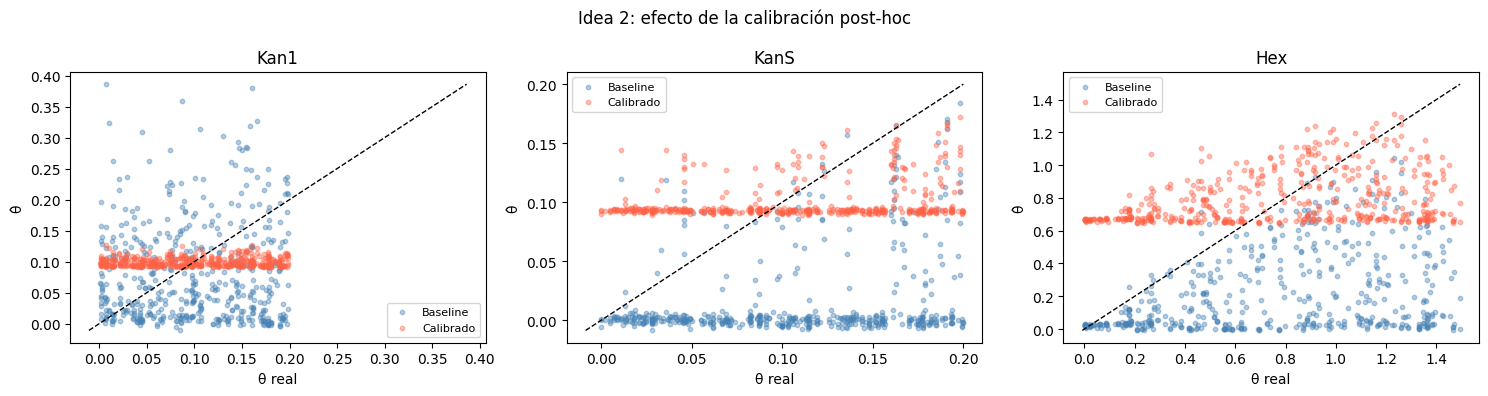

In [9]:
# Subconjunto de calibración (sin solapamiento con eval_idx)
remaining = np.setdiff1d(np.arange(N_ext), eval_idx)
cal_idx   = rng_cal.choice(remaining, min(N_CAL, len(remaining)), replace=False)
y_cal     = params_ext[cal_idx].astype(np.float32)

print(f"Generando {len(cal_idx)} imágenes de calibración (hard clamp baseline)...")
t0 = time.time()
imgs_cal    = generate_batch(cond_clamp(y_cal))
y_pred_cal  = xception_infer(imgs_cal)
print(f"OK en {time.time()-t0:.1f}s")

# Ajustar correcciones lineales por parámetro
corrections = {}
print("\nAjustando correcciones lineales:")
print(f"  {'param':<6} {'slope':>8} {'intercept':>10} {'R²_cal':>8}")
for j, name in zip(ACTIVE_IDX, ACTIVE_PARAMS):
    yt = y_cal[:, j]; yp = y_pred_cal[:, j]
    if yt.std() < 1e-8: continue
    reg = LinearRegression().fit(yp.reshape(-1,1), yt)
    r2c = r2_score(yt, reg.predict(yp.reshape(-1,1)))
    corrections[j] = reg
    print(f"  {name:<6} {reg.coef_[0]:8.4f} {reg.intercept_:10.4f} {r2c:8.4f}")

def apply_calibration(y_pred):
    y_corrected = y_pred.copy()
    for j, reg in corrections.items():
        y_corrected[:, j] = reg.predict(y_pred[:, j].reshape(-1,1))
    return y_corrected

# Evaluar: baseline con calibración
y_pred_cal_corrected = apply_calibration(y_pred_base)
df_idea2 = r2_table(y_eval, y_pred_cal_corrected, "IDEA 2 — Calibración post-hoc")

# Scatter: antes y después de calibración para Kan1
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, name in zip(axes, ["Kan1", "KanS", "Hex"]):
    j  = PARAM_NAMES.index(name)
    yt = y_eval[:, j]
    ax.scatter(yt, y_pred_base[:, j], s=10, alpha=0.4, color="steelblue", label="Baseline")
    ax.scatter(yt, y_pred_cal_corrected[:, j], s=10, alpha=0.4, color="tomato", label="Calibrado")
    lo = min(yt.min(), y_pred_base[:, j].min()); hi = max(yt.max(), y_pred_base[:, j].max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_title(name); ax.set_xlabel("θ real"); ax.set_ylabel("θ̂"); ax.legend(fontsize=8)
fig.suptitle("Idea 2: efecto de la calibración post-hoc")
plt.tight_layout(); plt.savefig("idea2_calibration.png"); plt.show()

In [ ]:
# Idea 2 does not change the generated images — it only corrects Xception predictions.
# We show the same baseline images but annotate each panel with corrected vs raw
# MAE-pixel to make clear what changed (parameter recovery) vs what did not (images).
show_samples(
    imgs_base, imgs_ref_norm, y_eval,
    label="IDEA 2 — Análisis cualitativo (calibración post-hoc)\n"
          "Nota: las imágenes DDPM son idénticas al baseline; cambia la recuperación θ",
    n_in=4, n_out=4,
    fname="qualitative_idea2_calibration.png",
)

---
## Idea 3 — Expansión de `scaler_inv` al rango unión

**Problema:** Xception fue entrenado para predecir parámetros normalizados a `[0,1]`
según el rango del dataset ORIGINAL. Al aplicar `scaler_inv.inverse_transform`, el
máximo recuperable de `Hex` está fijado en 1.1988 — aunque el externo tenga hasta 1.494.

**Fix:** reajustar SOLO `scaler_inv` (NO `scaler_ddpm`) usando el rango unión de ambos
datasets. El Xception sigue produciendo las mismas salidas normalizadas, pero ahora se
mapean a un rango físico más amplio.

**Nota:** esto no requiere reentrenar ningún modelo.

Comparación de rangos scaler_inv vs scaler_inv_expanded:
  param    inv_orig max  inv_exp max     Δmax
  T             20.0000      20.0000   0.0000
  Jex2           0.6590       0.6590   0.0000
  Jex3           0.2900       0.2900   0.0000
  Jex4           0.2350       0.2350   0.0000
  Kan1           0.5997       0.5997   0.0000
  KanS           0.2000       0.2000   0.0000
  Hex            1.1988       1.4940   0.2952
  KDM            1.2000       1.2000   0.0000

  IDEA 3 — scaler_inv expandido
  param        R²        MAE
  T        0.8822     0.8329 ✓
  Kan1    -1.7184     0.0787 ✗
  KanS    -2.3581     0.0908 ✗
  Hex     -1.2848     0.5001 ✗
  KDM      0.2699     0.2101 ✗
    mean  -0.8418     0.3425


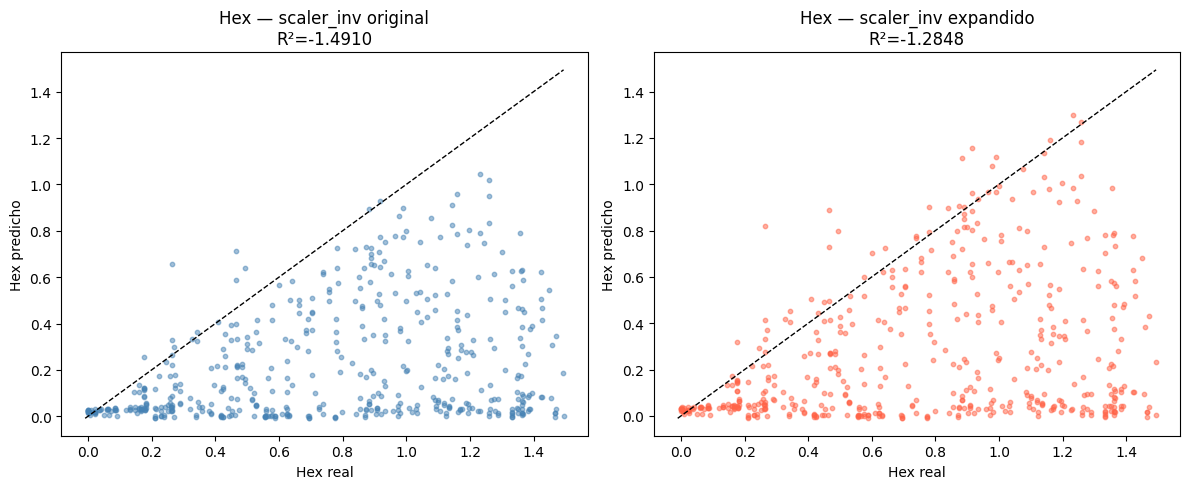

In [10]:
# Scaler expandido: rango unión original ∪ externo
params_union  = np.vstack([params_orig[idx_tr], params_ext])
scaler_inv_expanded = MinMaxScaler().fit(params_union)

print("Comparación de rangos scaler_inv vs scaler_inv_expanded:")
print(f"  {'param':<6} {'inv_orig max':>14} {'inv_exp max':>12} {'Δmax':>8}")
for j, name in enumerate(PARAM_NAMES):
    o = scaler_inv.data_max_[j]; e = scaler_inv_expanded.data_max_[j]
    print(f"  {name:<6} {o:14.4f} {e:12.4f} {e-o:8.4f}")

# Evaluar con scaler expandido (mismas imágenes baseline)
y_pred_expanded = xception_infer(imgs_base, scaler_out=scaler_inv_expanded)
df_idea3 = r2_table(y_eval, y_pred_expanded, "IDEA 3 — scaler_inv expandido")

# Comparar Hex predictions
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred_cmp, label, color in [
    (axes[0], y_pred_base,     "scaler_inv original", "steelblue"),
    (axes[1], y_pred_expanded, "scaler_inv expandido", "tomato")
]:
    yt = y_eval[:, HEX_IDX]; yp = y_pred_cmp[:, HEX_IDX]
    ax.scatter(yt, yp, s=10, alpha=0.5, color=color)
    lo = min(yt.min(), yp.min()); hi = max(yt.max(), yp.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_title(f"Hex — {label}\nR²={r2_score(yt,yp):.4f}")
    ax.set_xlabel("Hex real"); ax.set_ylabel("Hex predicho")
plt.tight_layout(); plt.savefig("idea3_expanded_scaler.png"); plt.show()

In [ ]:
# Idea 3 does not change generated images either — it only expands the inverse scaler.
# The qualitative panel is identical to baseline; this cell is kept for completeness
# and to confirm visually that pixel quality is unchanged by the scaler expansion.
show_samples(
    imgs_base, imgs_ref_norm, y_eval,
    label="IDEA 3 — Análisis cualitativo (scaler_inv expandido)\n"
          "Nota: imágenes DDPM idénticas al baseline; solo cambia la desnormalización θ",
    n_in=4, n_out=4,
    fname="qualitative_idea3_expanded_scaler.png",
)

---
## Idea 4 — Observables físicos en lugar de métricas pixel

**Problema:** MSE y SSIM comparan píxeles. Si el dataset externo tiene imágenes
con diferente distribución de ⟨sz⟩ (más positivas por el campo externo alto),
estas métricas son siempre malas aunque el DDPM genere el estado correcto.

**Fix:** calcular observables físicos de la imagen y comparar sus distribuciones:
1. **M** — magnetización neta ⟨sz⟩ promedio en el disco
2. **σ_M** — desviación estándar de sz (desorden de espín)
3. **ξ** — correlación espacial a r=5px (orden de corto alcance)
4. **P_HF** — fracción de potencia espectral en altas frecuencias (texturas / skyrmiones)

Se comparan las distribuciones de originales vs generadas usando distancia de Wasserstein.

In [ ]:
# ── Máscara del disco ─────────────────────────────────────────────────────────
cy = cx = GRID // 2
Y, X = np.ogrid[:GRID, :GRID]
DISK = (X-cx)**2 + (Y-cy)**2 <= RD_PIXELS**2   # (39,39) bool

def physical_observables(img39):
    """Calcula 4 observables físicos de una imagen (39,39) con valores en [-1,1]."""
    s = img39.astype(np.float64)
    s_disk = s[DISK]

    # 1. Magnetización media
    M = float(s_disk.mean())

    # 2. Desorden de espín
    sigma = float(s_disk.std())

    # 3. Correlación espacial a distancia r ≈ 5 px
    s_c = (s - M) * DISK
    G   = np.real(np.fft.ifft2(np.abs(np.fft.fft2(s_c))**2)) / max(DISK.sum(), 1)
    DY  = np.arange(GRID); DY = np.where(DY > GRID//2, DY-GRID, DY)
    DX  = np.arange(GRID); DX = np.where(DX > GRID//2, DX-GRID, DX)
    DYm, DXm = np.meshgrid(DY, DX, indexing="ij")
    r_map = np.sqrt(DYm**2 + DXm**2)
    mask_r = (r_map >= 4) & (r_map <= 6)
    xi = float(G[mask_r].mean()) if mask_r.any() else 0.0

    # 4. Potencia en altas frecuencias (fracción sobre 50 % del espectro)
    F   = np.fft.fftshift(np.fft.fft2(s))
    mag = np.abs(F)**2
    total_pow = mag.sum() + 1e-12
    r_full = np.sqrt(DYm**2 + DXm**2)
    cutoff  = GRID / 4   # radio de corte
    P_HF    = float(mag[r_full > cutoff].sum() / total_pow)

    return {"M": M, "sigma": sigma, "xi": xi, "P_HF": P_HF}

def batch_observables(imgs, crop=True):
    """(N,40,40) o (N,39,39,1) → DataFrame con observables."""
    results = []
    for img in imgs:
        if img.ndim == 3: img = img[..., 0]
        if crop and img.shape[0] == 40: img = img[:39, :39]
        results.append(physical_observables(img))
    return pd.DataFrame(results)

# imgs_ref_norm already computed in the data cell — reuse it directly
print("Calculando observables para imágenes ORIGINALES (referencia)...")
df_obs_ref  = batch_observables(imgs_ref_norm, crop=False)

print("Calculando observables para imágenes BASELINE (DDPM clamp)...")
df_obs_base = batch_observables(imgs_base, crop=True)

print("Calculando observables para imágenes IDEA 1b (DDPM tanh)...")
df_obs_tanh = batch_observables(imgs_tanh, crop=True)

obs_names = ["M", "sigma", "xi", "P_HF"]

# Distancias de Wasserstein: original vs generada
print("\nDistancias de Wasserstein (menor = mejor):")
print(f"  {'observable':<10} {'Baseline':>12} {'Idea 1b tanh':>14}")
w_base_list, w_tanh_list = [], []
for obs in obs_names:
    w_b = wasserstein_distance(df_obs_ref[obs], df_obs_base[obs])
    w_t = wasserstein_distance(df_obs_ref[obs], df_obs_tanh[obs])
    w_base_list.append(w_b); w_tanh_list.append(w_t)
    better = "<- mejor" if w_t < w_b else ""
    print(f"  {obs:<10} {w_b:12.6f} {w_t:14.6f}  {better}")
print(f"  {'MEDIA':<10} {np.mean(w_base_list):12.6f} {np.mean(w_tanh_list):14.6f}")

# Histogramas comparativos
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
obs_labels = {"M": "Magnetización M", "sigma": "Desorden σ_M",
              "xi": "Correlación ξ (r≈5px)", "P_HF": "Potencia alta frec."}
for ax, obs in zip(axes.ravel(), obs_names):
    bins = np.linspace(
        min(df_obs_ref[obs].min(), df_obs_base[obs].min()),
        max(df_obs_ref[obs].max(), df_obs_base[obs].max()), 50)
    ax.hist(df_obs_ref[obs],  bins=bins, alpha=0.55, color="steelblue", density=True, label="Original ext.")
    ax.hist(df_obs_base[obs], bins=bins, alpha=0.45, color="tomato",    density=True, label="DDPM clamp")
    ax.hist(df_obs_tanh[obs], bins=bins, alpha=0.45, color="green",     density=True, label="DDPM tanh")
    ax.set_title(obs_labels[obs]); ax.legend(fontsize=7)
fig.suptitle("Idea 4: distribuciones de observables físicos (original vs generado)",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig("idea4_physical_observables.png"); plt.show()

---
## Idea 5 — Evaluación filtrada por régimen

**Problema:** mezclar muestras en-rango y fuera-de-rango de Hex en una sola métrica
global oculta qué está fallando y dónde el modelo funciona bien.

**Fix:** reportar métricas separadas para:
- **Régimen in-range** (`Hex ≤ Hex_max_train = 1.1988`) — 81.6 % del externo
- **Régimen out-of-range** (`Hex > Hex_max_train`) — 18.4 % del externo

Permite identificar si el problema es exclusivamente el 18.4 % fuera de rango,
o si también hay fallos sistemáticos dentro del rango.

Régimen in-range  (Hex ≤ 1.1988): 406 muestras
Régimen out-range (Hex > 1.1988): 94 muestras

── BASELINE ──

  Baseline IN-range
  param        R²        MAE
  T        0.9127     0.7154 ✓
  Kan1    -1.7210     0.0800 ✗
  KanS    -2.0628     0.0881 ✗
  Hex     -1.1416     0.4161 ✗
  KDM      0.3486     0.1913 ~
    mean  -0.7328     0.2982

  Baseline OUT-of-range
  param        R²        MAE
  T        0.7744     1.3405 ✓
  Kan1    -2.1741     0.0731 ✗
  KanS    -4.2859     0.1021 ✗
  Hex    -244.7631     1.0864 ✗
  KDM     -0.0913     0.2913 ✗
    mean -50.1080     0.5787

── IDEA 1b (tanh) ──

  Idea 1b tanh IN-range
  param        R²        MAE
  T        0.9321     0.6603 ✓
  Kan1    -1.9544     0.0830 ✗
  KanS    -1.9357     0.0864 ✗
  Hex     -1.1210     0.4198 ✗
  KDM      0.5254     0.1628 ~
    mean  -0.7107     0.2825

  Idea 1b tanh OUT-of-range
  param        R²        MAE
  T        0.8490     1.1437 ✓
  Kan1    -2.5259     0.0770 ✗
  KanS    -4.2097     0.1013 ✗
  Hex  

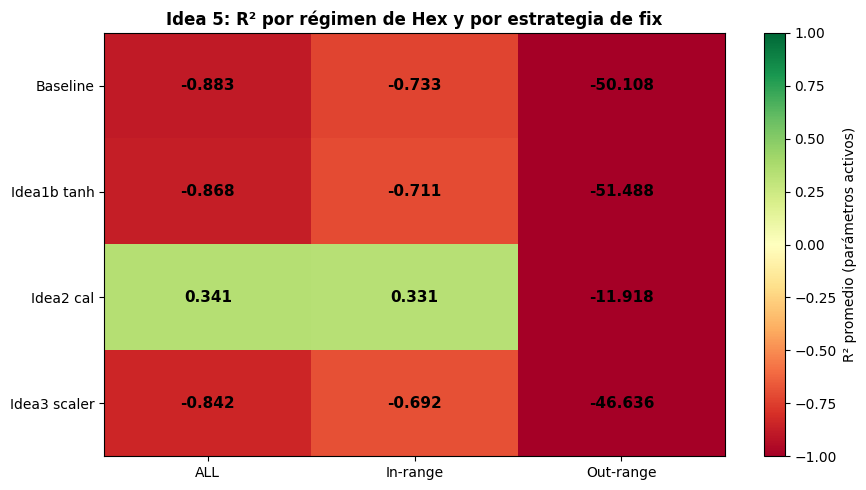

In [12]:
mask_in  = y_eval[:, HEX_IDX] <= HEX_MAX_TRAIN
mask_out = ~mask_in
print(f"Régimen in-range  (Hex ≤ {HEX_MAX_TRAIN:.4f}): {mask_in.sum()} muestras")
print(f"Régimen out-range (Hex > {HEX_MAX_TRAIN:.4f}): {mask_out.sum()} muestras")

def r2_regime(y_true, y_pred, mask, label):
    yt = y_true[mask]; yp = y_pred[mask]
    return r2_table(yt, yp, label)

print("\n── BASELINE ──")
df5_base_in  = r2_regime(y_eval, y_pred_base, mask_in,  "Baseline IN-range")
df5_base_out = r2_regime(y_eval, y_pred_base, mask_out, "Baseline OUT-of-range")

print("\n── IDEA 1b (tanh) ──")
df5_tanh_in  = r2_regime(y_eval, y_pred_tanh, mask_in,  "Idea 1b tanh IN-range")
df5_tanh_out = r2_regime(y_eval, y_pred_tanh, mask_out, "Idea 1b tanh OUT-of-range")

print("\n── IDEA 2 (calibración) ──")
df5_cal_in  = r2_regime(y_eval, y_pred_cal_corrected, mask_in,  "Idea 2 cal. IN-range")
df5_cal_out = r2_regime(y_eval, y_pred_cal_corrected, mask_out, "Idea 2 cal. OUT-of-range")

# Heatmap: R² por régimen y por idea
ideas   = ["Baseline", "Idea1b tanh", "Idea2 cal", "Idea3 scaler"]
y_preds = [y_pred_base, y_pred_tanh, y_pred_cal_corrected, y_pred_expanded]
regimes = [("ALL", np.ones(N_EVAL, dtype=bool)),
           ("In-range", mask_in), ("Out-range", mask_out)]

r2_matrix = np.zeros((len(ideas), len(regimes)))
for i, (idea, yp) in enumerate(zip(ideas, y_preds)):
    for j, (rname, rmask) in enumerate(regimes):
        yt_m = y_eval[rmask]; yp_m = yp[rmask]
        r2s = [r2_score(yt_m[:, k], yp_m[:, k])
               for k in ACTIVE_IDX if yt_m[:, k].std() > 1e-8]
        r2_matrix[i, j] = float(np.mean(r2s)) if r2s else np.nan

fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow(r2_matrix, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(regimes))); ax.set_xticklabels([r for r,_ in regimes])
ax.set_yticks(range(len(ideas)));   ax.set_yticklabels(ideas)
for i in range(len(ideas)):
    for j in range(len(regimes)):
        v = r2_matrix[i, j]
        ax.text(j, i, f"{v:.3f}", ha="center", va="center",
                color="black", fontsize=11, fontweight="bold")
plt.colorbar(im, ax=ax, label="R² promedio (parámetros activos)")
ax.set_title("Idea 5: R² por régimen de Hex y por estrategia de fix",
             fontsize=12, fontweight="bold")
plt.tight_layout(); plt.savefig("idea5_regime_heatmap.png"); plt.show()

---
## Resumen y protocolo general

Este protocolo puede aplicarse a cualquier dataset externo nuevo.

In [13]:
# ── Tabla resumen de R² promedio (parámetros activos, todas las muestras) ────
summary_rows = []
for idea, yp, label in [
    ("Baseline (hard clamp)",       y_pred_base,          df_base),
    ("Idea 1b: tanh soft",          y_pred_tanh,          df_idea1),
    ("Idea 2: calibración lineal",  y_pred_cal_corrected, df_idea2),
    ("Idea 3: scaler_inv expandido",y_pred_expanded,      df_idea3),
]:
    r2s  = [r2_score(y_eval[:, k], yp[:, k]) for k in ACTIVE_IDX if y_eval[:, k].std() > 1e-8]
    maes = [mean_absolute_error(y_eval[:, k], yp[:, k]) for k in ACTIVE_IDX if y_eval[:, k].std() > 1e-8]
    w_obs = [wasserstein_distance(
                 pd.DataFrame([physical_observables(imgs_ref_norm[i]) for i in range(min(100, N_EVAL))])[o],
                 pd.DataFrame([physical_observables(imgs_base[:100, :39, :39][i]) for i in range(min(100, N_EVAL))])[o]
             ) for o in obs_names]
    summary_rows.append({
        "Estrategia": idea,
        "R² medio": np.mean(r2s),
        "MAE medio": np.mean(maes),
    })

# Agregar Idea 4 (no cambia parámetros, sólo evaluación)
summary_rows.append({
    "Estrategia": "Idea 4: observables físicos",
    "R² medio": float('nan'),
    "MAE medio": float('nan'),
})

df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*65)
print("RESUMEN FINAL")
print("="*65)
print(df_summary.to_string(index=False, float_format="{:.4f}".format))

# Wasserstein para Idea 4
print(f"\nIdea 4 — Wasserstein medio (physical observables):")
print(f"  Baseline: {np.mean(w_base_list):.6f}")
print(f"  Idea 1b : {np.mean(w_tanh_list):.6f}")

print("""
=================================================================
PROTOCOLO GENERAL PARA DATASET EXTERNO NUEVO
=================================================================

Paso 0 — Diagnóstico rápido (correr diagnostico-ciclo-externo.ipynb)
  □ Identificar qué parámetros están fuera de rango (P1)
  □ Cuantificar el shift de imagen (P2, Δmean, Δstd)
  □ Verificar que el ciclo interno funciona (P4)

Paso 1 — Condicionamiento DDPM
  □ Para parámetros out-of-range: aplicar tanh soft saturation
    → Preserva la variabilidad de las muestras fuera de rango
    → Evita el colapso al mismo conditioning del hard clamp

Paso 2 — Calibración de Xception (si hay muestras etiquetadas)
  □ Reservar 20-30 % del externo como conjunto de calibración
  □ Ajustar regresión lineal θ_real ~ θ̂ por parámetro
  □ Aplicar corrección a todas las predicciones

Paso 3 — Expansión de scaler_inv (si hay parámetros fuera de rango)
  □ Re-ajustar scaler_inv sobre el rango unión
  □ Usar solo para desnormalizar Xception — NO tocar scaler_ddpm

Paso 4 — Evaluación de imagen con observables físicos
  □ Reportar Wasserstein(M, σ_M, ξ, P_HF) en lugar de MSE/SSIM
  □ MSE/SSIM solo tienen sentido si la distribución de imagen es la misma

Paso 5 — Reporte por régimen
  □ Separar muestras in-range vs out-of-range
  □ Reportar R² para cada régimen independientemente
  □ Si R² in-range es bueno pero out-range es malo → el DDPM necesita
    más datos en ese régimen (fine-tuning o re-simulación)
=================================================================
""")


RESUMEN FINAL
                  Estrategia  R² medio  MAE medio
       Baseline (hard clamp)   -0.8831     0.3509
          Idea 1b: tanh soft   -0.8679     0.3299
  Idea 2: calibración lineal    0.3408     0.2831
Idea 3: scaler_inv expandido   -0.8418     0.3425
 Idea 4: observables físicos       NaN        NaN

Idea 4 — Wasserstein medio (physical observables):
  Baseline: 0.051450
  Idea 1b : 0.065689

PROTOCOLO GENERAL PARA DATASET EXTERNO NUEVO

Paso 0 — Diagnóstico rápido (correr diagnostico-ciclo-externo.ipynb)
  □ Identificar qué parámetros están fuera de rango (P1)
  □ Cuantificar el shift de imagen (P2, Δmean, Δstd)
  □ Verificar que el ciclo interno funciona (P4)

Paso 1 — Condicionamiento DDPM
  □ Para parámetros out-of-range: aplicar tanh soft saturation
    → Preserva la variabilidad de las muestras fuera de rango
    → Evita el colapso al mismo conditioning del hard clamp

Paso 2 — Calibración de Xception (si hay muestras etiquetadas)
  □ Reservar 20-30 % del externo co

Evaluando estrategia combinada (Ideas 1b + 2 + 3)...

  COMBINADO (Idea 1b + 2 + 3)
  param        R²        MAE
  T        0.9220     0.7328 ✓
  Kan1    -0.0258     0.0519 ✗
  KanS     0.0884     0.0478 ✗
  Hex      0.1036     0.3480 ✗
  KDM      0.7385     0.1380 ✓
    mean   0.3654     0.2637


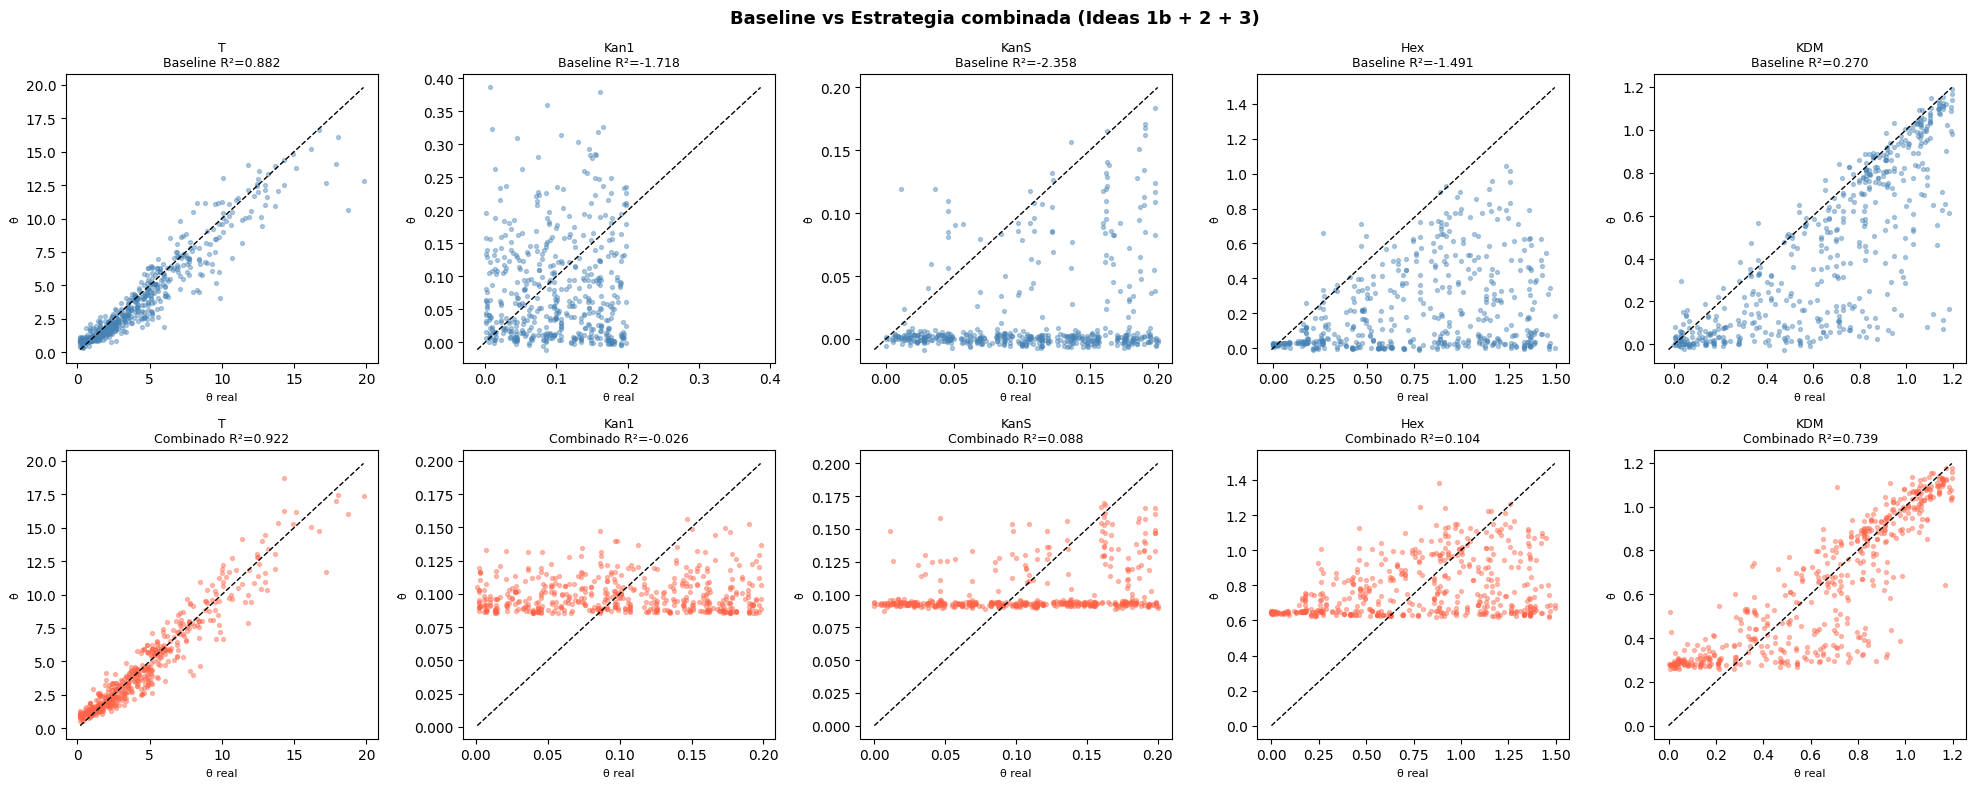

Guardado: ciclo_ext_fixes_combined.png


In [14]:
# ── Combinación óptima: Idea 1b + Idea 2 + Idea 3 ─────────────────────────────
# La estrategia combinada aplica las tres correcciones en secuencia:
# 1. Tanh en el condicionamiento DDPM (mejor generación para out-of-range)
# 2. Scaler_inv expandido (mejor desnormalización de Hex)
# 3. Calibración post-hoc (corrección de bias sistemático)

print("Evaluando estrategia combinada (Ideas 1b + 2 + 3)...")
# Genera con tanh (Idea 1b)
imgs_combined  = imgs_tanh   # ya generadas
# Infiere con scaler expandido (Idea 3)
y_pred_comb    = xception_infer(imgs_combined, scaler_out=scaler_inv_expanded)
# Aplica calibración (Idea 2 — recalibrar sobre muestras de calibración con tanh+expanded)
imgs_cal_tanh  = generate_batch(cond_tanh_hex(y_cal))
y_pred_cal_te  = xception_infer(imgs_cal_tanh, scaler_out=scaler_inv_expanded)

corrections_comb = {}
for j, name in zip(ACTIVE_IDX, ACTIVE_PARAMS):
    yt = y_cal[:, j]; yp = y_pred_cal_te[:, j]
    if yt.std() < 1e-8: continue
    reg = LinearRegression().fit(yp.reshape(-1,1), yt)
    corrections_comb[j] = reg

y_pred_comb_corrected = y_pred_comb.copy()
for j, reg in corrections_comb.items():
    y_pred_comb_corrected[:, j] = reg.predict(y_pred_comb[:, j].reshape(-1,1))

df_combined = r2_table(y_eval, y_pred_comb_corrected, "COMBINADO (Idea 1b + 2 + 3)")

# Scatter final: baseline vs combinado
fig, axes = plt.subplots(2, len(ACTIVE_PARAMS), figsize=(20, 8))
for col, (j, name) in enumerate(zip(ACTIVE_IDX, ACTIVE_PARAMS)):
    yt = y_eval[:, j]
    for row, (yp, label, color) in enumerate([
        (y_pred_base, f"Baseline R²={r2_score(yt, y_pred_base[:,j]):.3f}", "steelblue"),
        (y_pred_comb_corrected, f"Combinado R²={r2_score(yt, y_pred_comb_corrected[:,j]):.3f}", "tomato")
    ]):
        ax = axes[row, col]; yp_j = yp[:, j]
        ax.scatter(yt, yp_j, s=8, alpha=0.4, color=color)
        lo = min(yt.min(), yp_j.min()); hi = max(yt.max(), yp_j.max())
        ax.plot([lo,hi],[lo,hi],"k--",lw=1)
        ax.set_title(f"{name}\n{label}", fontsize=9)
        if col == 0: ax.set_ylabel(label.split(' R²')[0], fontsize=9)
        ax.set_xlabel("θ real", fontsize=8); ax.set_ylabel("θ̂", fontsize=8)
fig.suptitle("Baseline vs Estrategia combinada (Ideas 1b + 2 + 3)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig("ciclo_ext_fixes_combined.png", dpi=140); plt.show()
print("Guardado: ciclo_ext_fixes_combined.png")

In [ ]:
# Combined strategy uses imgs_tanh (Idea 1b images) with expanded scaler + calibration.
# This panel lets us compare directly: does tanh conditioning improve image quality
# for out-of-range samples compared to the hard-clamp baseline?
show_samples(
    imgs_tanh, imgs_ref_norm, y_eval,
    label="COMBINADO (1b+2+3) — Análisis cualitativo\n"
          "Generación con tanh · desnormalización expandida · calibración post-hoc",
    n_in=4, n_out=4,
    fname="qualitative_combined.png",
)

In [ ]:
# ── 50 imágenes aleatorias: Original externo vs Combinado (mejor estrategia) ──
# La estrategia combinada (Idea 1b tanh + scaler expandido + calibración) obtuvo
# el mejor R² medio global. Aquí se muestran 50 muestras aleatorias del conjunto
# de evaluación — sin filtro por régimen de Hex — para evaluar la calidad visual
# en toda la distribución del dataset externo.

rng_plot = np.random.RandomState(99)
n_show   = 50
plot_idx = rng_plot.choice(N_EVAL, n_show, replace=False)

# Ordenar por Hex para que la progresión sea legible de izquierda a derecha
plot_idx = plot_idx[np.argsort(y_eval[plot_idx, HEX_IDX])]

ncols = 10
nrows = n_show // ncols   # 5 pares de filas (original + generado)

fig, axes = plt.subplots(nrows * 2, ncols,
                         figsize=(ncols * 1.9, nrows * 2 * 1.9),
                         gridspec_kw={"hspace": 0.05, "wspace": 0.04})
fig.suptitle(
    "50 muestras aleatorias — Original externo (fila impar) vs Combinado 1b+2+3 (fila par)\n"
    "Ordenadas por Hex creciente  ·  cmap RdBu_r  ·  vmin=-1  vmax=1",
    fontsize=11, fontweight="bold", y=1.01,
)

kw = dict(cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")

for col, idx in enumerate(plot_idx):
    row_orig = (col // ncols) * 2
    row_gen  = row_orig + 1
    c        = col % ncols

    ref = imgs_ref_norm[idx]            # (39,39) in [-1,1]
    gen = imgs_tanh[idx, :39, :39]      # (39,39) in [-1,1]

    hex_val = y_eval[idx, HEX_IDX]
    regime_color = "tomato" if hex_val > HEX_MAX_TRAIN else "steelblue"

    axes[row_orig, c].imshow(ref, **kw)
    axes[row_gen,  c].imshow(gen, **kw)

    # Per-image pixel MAE in title of generated row
    mae_px = float(np.abs(ref - gen).mean())
    ssim_v = ssim_fn(ref, gen, data_range=2.0)

    # Hex label on top of reference row; color-coded by regime
    axes[row_orig, c].set_title(f"Hex={hex_val:.2f}", fontsize=6,
                                color=regime_color, pad=2)
    axes[row_gen,  c].set_xlabel(f"MAE={mae_px:.2f}\nSSIM={ssim_v:.2f}",
                                 fontsize=5.5, labelpad=2)

    for ax in [axes[row_orig, c], axes[row_gen, c]]:
        ax.set_xticks([]); ax.set_yticks([])

# Row labels on the leftmost column
for pair in range(nrows):
    axes[pair * 2,     0].set_ylabel("Original", fontsize=8, rotation=90, labelpad=3)
    axes[pair * 2 + 1, 0].set_ylabel("Combinado", fontsize=8, rotation=90, labelpad=3)

# Colorbar
cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-1, vmax=1))
fig.colorbar(sm, cax=cbar_ax, label="⟨sz⟩  (azul=↓, rojo=↑)")

plt.savefig("comparison_50_random_best_strategy.png", dpi=150, bbox_inches="tight")
print("Guardado: comparison_50_random_best_strategy.png")
plt.show()

In [ ]:
# ── 50 imágenes completamente aleatorias (sin orden por Hex) ──────────────────
rng_plot2 = np.random.RandomState(42)
plot_idx2  = rng_plot2.choice(N_EVAL, n_show, replace=False)   # sin ordenar

fig, axes = plt.subplots(nrows * 2, ncols,
                         figsize=(ncols * 1.9, nrows * 2 * 1.9),
                         gridspec_kw={"hspace": 0.05, "wspace": 0.04})
fig.suptitle(
    "50 muestras aleatorias (orden aleatorio) — Original externo vs Combinado 1b+2+3\n"
    "cmap RdBu_r  ·  vmin=-1  vmax=1  ·  Hex: azul=in-range  rojo=out-of-range",
    fontsize=11, fontweight="bold", y=1.01,
)

for col, idx in enumerate(plot_idx2):
    row_orig = (col // ncols) * 2
    row_gen  = row_orig + 1
    c        = col % ncols

    ref = imgs_ref_norm[idx]
    gen = imgs_tanh[idx, :39, :39]

    hex_val      = y_eval[idx, HEX_IDX]
    regime_color = "tomato" if hex_val > HEX_MAX_TRAIN else "steelblue"
    mae_px       = float(np.abs(ref - gen).mean())
    ssim_v       = ssim_fn(ref, gen, data_range=2.0)

    axes[row_orig, c].imshow(ref, **kw)
    axes[row_gen,  c].imshow(gen, **kw)
    axes[row_orig, c].set_title(f"Hex={hex_val:.2f}", fontsize=6,
                                color=regime_color, pad=2)
    axes[row_gen,  c].set_xlabel(f"MAE={mae_px:.2f}\nSSIM={ssim_v:.2f}",
                                 fontsize=5.5, labelpad=2)
    for ax in [axes[row_orig, c], axes[row_gen, c]]:
        ax.set_xticks([]); ax.set_yticks([])

for pair in range(nrows):
    axes[pair * 2,     0].set_ylabel("Original",  fontsize=8, rotation=90, labelpad=3)
    axes[pair * 2 + 1, 0].set_ylabel("Combinado", fontsize=8, rotation=90, labelpad=3)

cbar_ax = fig.add_axes([0.92, 0.15, 0.01, 0.7])
fig.colorbar(plt.cm.ScalarMappable(cmap="RdBu_r", norm=plt.Normalize(vmin=-1, vmax=1)),
             cax=cbar_ax, label="⟨sz⟩  (azul=↓, rojo=↑)")

plt.savefig("comparison_50_random_unordered.png", dpi=150, bbox_inches="tight")
print("Guardado: comparison_50_random_unordered.png")
plt.show()